<a href="https://colab.research.google.com/github/BYU-Hydroinformatics/pybfs/blob/main/notebooks/pybfs_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baseflow Separation with PyBFS

This notebook illustrates how to install PyBFS, how to run a basic baseflow separation analysis using the main bfs function, and then how to create a short-term baseflow forecast.

Full documentation can be found here: https://pybfs.readthedocs.io/en/latest/

In [1]:
%%capture
!pip install pybfs

In [2]:
import pybfs
import pandas as pd
import numpy as np
import pybfs
from google.colab import files
import io

## Upload streamflow file

In [3]:
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  filename = next(iter(uploaded))
  streamflow_df = pd.read_csv(io.BytesIO(uploaded[filename]))
  print(f"Successfully loaded '{filename}' into streamflow_df.")
  display(streamflow_df.head())

Saving 2312200_data.csv to 2312200_data.csv
User uploaded file "2312200_data.csv" with length 7978 bytes
Successfully loaded '2312200_data.csv' into streamflow_df.


,Date,Streamflow
0,1/1/2018,28869.54394
1,1/2/2018,27156.94387
2,1/3/2018,34252.00128
3,1/4/2018,36453.91565
4,1/5/2018,33762.68698


## Upload parameters file

In [4]:
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  filename = next(iter(uploaded))
  params_df = pd.read_csv(io.BytesIO(uploaded[filename]))
  print(f"Successfully loaded '{filename}' into streamflow_df.")
  display(params_df.head())

Saving bfs_params_50.csv to bfs_params_50.csv
User uploaded file "bfs_params_50.csv" with length 7542 bytes
Successfully loaded 'bfs_params_50.csv' into streamflow_df.


,site_no,AREA,Lb,X1,Wb,POR,ALPHA,BETA,Ks,Kb,Kz,Qthresh,Rs,Rb1,Rb2,Prec,Frac4Rise,Error,BFF
0,2193340,86784000,7040.94,139.115,668.407,0.15,0.024473,1.0,888.045,18106.30,1.284760,455062.0,-0.128897,-0.106304,-0.139495,185.939,0.05,1.270,0.333122
1,2338523,43008000,14808.30,3270.740,767.153,0.15,0.012621,9.4,904.124,3133.81,2.245520,535799.0,-0.202980,-0.069092,-0.040290,17952.900,0.05,0.327,0.446286
2,2339495,221184000,9628.05,100.000,631.935,0.15,0.011264,1.0,879.480,9247.48,0.871429,24955.0,-0.225443,-0.066735,-0.021045,2493.060,0.05,0.351,0.428190
3,2343225,755200000,23967.80,100.000,354.965,0.15,0.023006,1.0,2771.080,4911.18,0.857941,13893.1,-0.202733,-0.083872,-0.031210,1426.350,0.05,0.509,0.266504
4,2343940,164352000,12082.20,4905.590,574.199,0.15,0.010840,9.1,695.440,4849.63,1.097200,94193.0,-0.228283,-0.076135,-0.035086,2219.770,0.05,0.302,0.383719


## Get parameters for site

In [5]:
site_number = 2312200
print(f"Extracting parameters for site {site_number}...")
basin_char, gw_hyd, flow = pybfs.get_values_for_site(params_df, site_number)

# Extract basin characteristics
area, lb, x1, wb, por = basin_char[0], basin_char[1], basin_char[2], basin_char[3], basin_char[4]
ws = wb / 2

# Extract groundwater hydraulic parameters
alpha, beta, ks, kb, kz = gw_hyd[0], gw_hyd[1], gw_hyd[2], gw_hyd[3], gw_hyd[4]

# Extract flow metrics
qthresh, rs, rb1, rb2, prec, fr4rise = flow[0], flow[1], flow[2], flow[3], flow[4], flow[5]

print(f"\nBasin characteristics:")
print(f"  Area: {area}, Length: {lb}, Width: {wb}")
print(f"  Porosity: {por}")

Extracting parameters for site 2312200...

Basin characteristics:
  Area: 371200000.0, Length: 19383.1, Width: 420.959
  Porosity: 0.15


## Generate baseflow table and run bfs


Generating baseflow table...
Baseflow table generated with 1001 rows

Running BFS baseflow separation...
BFS completed for 365 time steps

=== Results Summary ===
Total observed flow: 85129801.65
Total simulated flow: 57936893.91
Total baseflow: 39658655.17
Total surface flow: 13483053.05
Total direct runoff: 4823002.45

Plotting baseflow simulation...


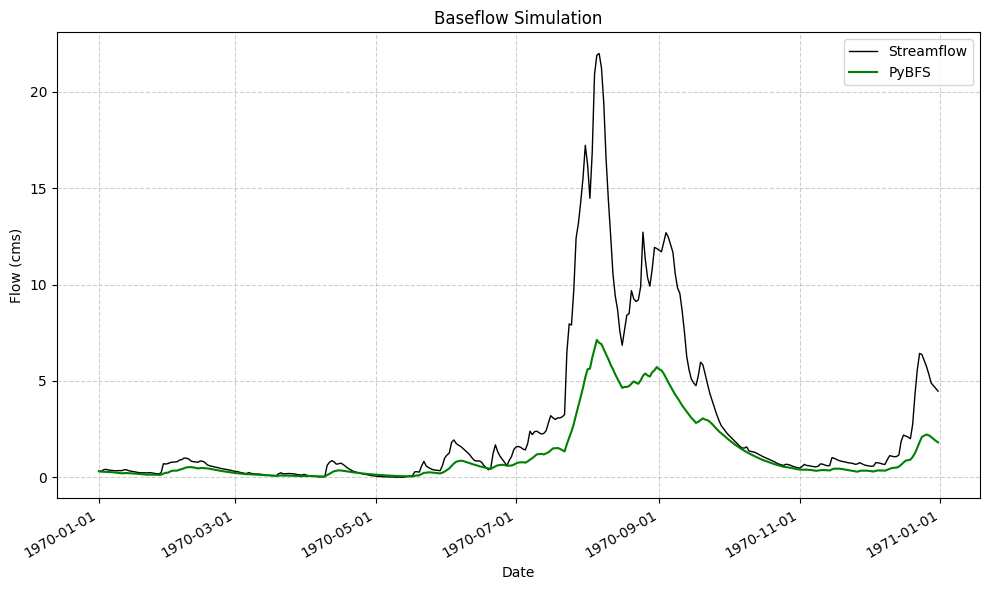

In [6]:
# Generate baseflow table
print("\nGenerating baseflow table...")
SBT = pybfs.base_table(lb, x1, wb, beta, kb, streamflow_df, por)
print(f"Baseflow table generated with {len(SBT)} rows")

# Run BFS
print("\nRunning BFS baseflow separation...")
result = pybfs.bfs(streamflow_df, SBT, basin_char, gw_hyd, flow)
print(f"BFS completed for {len(result)} time steps")

# Display summary statistics
print("\n=== Results Summary ===")
print(f"Total observed flow: {result['Qob'].sum():.2f}")
print(f"Total simulated flow: {result['Qsim'].sum():.2f}")
print(f"Total baseflow: {result['Baseflow'].sum():.2f}")
print(f"Total surface flow: {result['SurfaceFlow'].sum():.2f}")
print(f"Total direct runoff: {result['DirectRunoff'].sum():.2f}")

# Plot results
print("\nPlotting baseflow simulation...")
pybfs.plot_baseflow_simulation(streamflow_df, result)

## Peform forecasting

Running BFS for training period (2018-01-01 to 2018-09-30)...
Initial conditions extracted from 2018-09-30 00:00:00

Forecasting for period 2018-10-01 to 2018-11-30...
Forecast completed for 61 time steps

Plotting training + forecast baseflow...


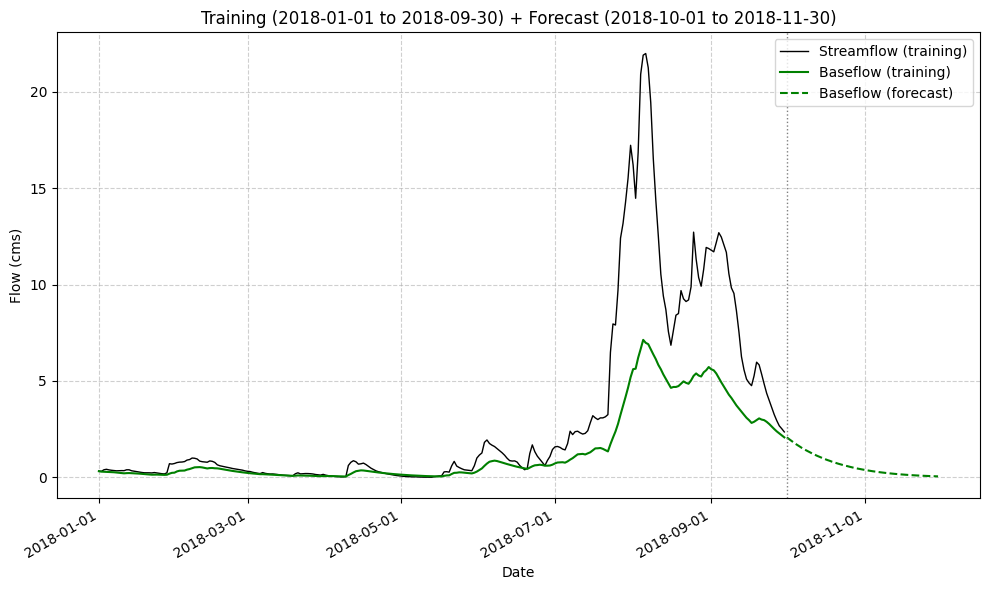

In [7]:
# Filter data for training period (Jan-Sep 2018)
start_date = '2018-01-01'
end_date = '2018-09-30'

# Convert 'Date' column to datetime objects for proper filtering
streamflow_df['Date'] = pd.to_datetime(streamflow_df['Date'])

streamflow_filtered_df = streamflow_df[
    (streamflow_df['Date'] >= start_date) & (streamflow_df['Date'] <= end_date)
]

print(f"Running BFS for training period ({start_date} to {end_date})...")
tmp2 = pybfs.bfs(streamflow_filtered_df, SBT, basin_char, gw_hyd, flow)

# Extract initial conditions from last time step
Xi, Zbi, Zsi, StBi, StSi, Surflow, Baseflow, Rech = tmp2.iloc[-1][
    ['X', 'Zb.L', 'Zs.L', 'StBase', 'StSur', 'SurfaceFlow', 'Baseflow', 'Rech']
]
ini = (Xi, Zbi, Zsi, StBi, StSi, Surflow, Baseflow, Rech)

print(f"Initial conditions extracted from {tmp2.iloc[-1]['Date']}")

# Create forecast period (Oct-Nov 2018)
dates = pd.date_range(start="2018-10-01", end="2018-11-30", freq="D")
forecast_df = pd.DataFrame({
    "date": dates,
    "streamflow": np.nan
})

print(f"\nForecasting for period 2018-10-01 to 2018-11-30...")
f = pybfs.forecast(forecast_df, SBT, basin_char, gw_hyd, flow, ini)
print(f"Forecast completed for {len(f)} time steps")

# Plot training (solid) + forecast (dashed) in one figure
forecast_start = "2018-10-01"
forecast_end = "2018-11-30"
print("\nPlotting training + forecast baseflow...")
pybfs.plot_forecast(
    training_streamflow=streamflow_filtered_df,
    training_bfs=tmp2,
    forecast_data=f,
    title=f"Training ({start_date} to {end_date}) + Forecast ({forecast_start} to {forecast_end})",
)
